In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

Running ensemble simulations...


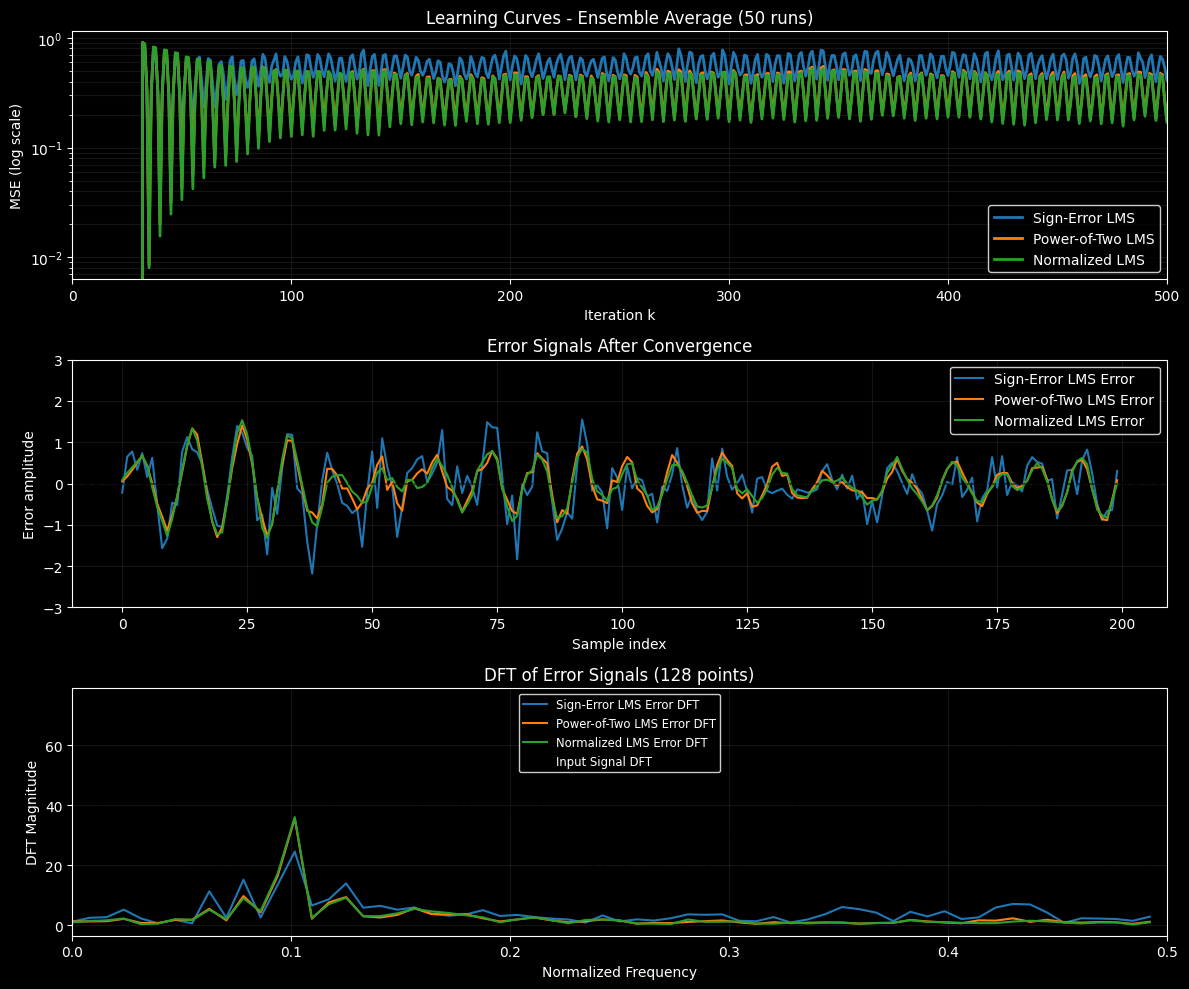

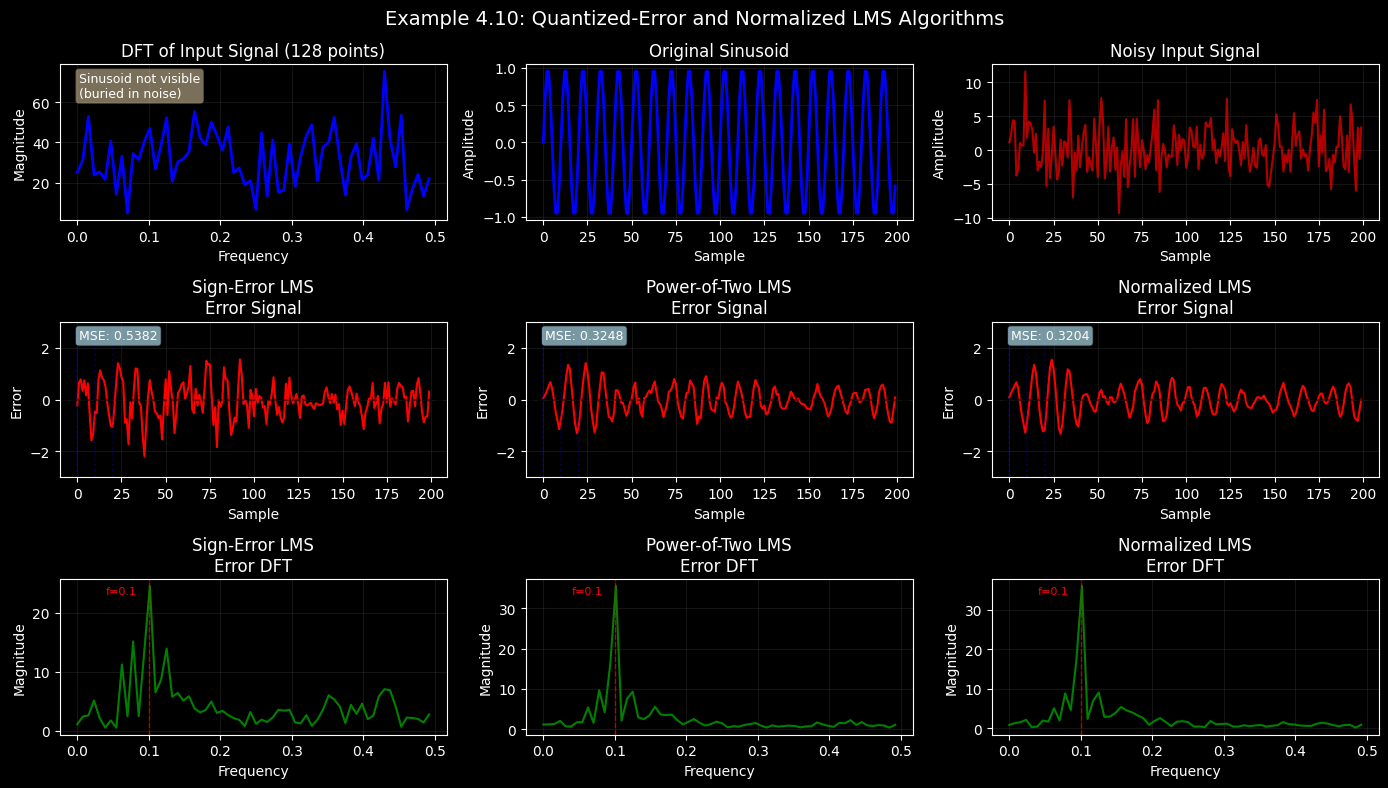


PERFORMANCE COMPARISON
Algorithm            Final MSE    Convergence Speed    SNR Improvement
----------------------------------------------------------------------
Sign-Error LMS       0.385046     0                    +12.51          dB
Power-of-Two LMS     0.241373     0                    +14.70          dB
Normalized LMS       0.242065     0                    +14.76          dB

Input SNR: -12.82 dB

Observations:
1. Normalized LMS converges faster due to adaptive step-size normalization
2. Quantized-error algorithms (Sign-Error, Power-of-Two) have similar convergence
3. Error DFT reveals the sinusoid frequency (0.1) after convergence
4. High MSE after convergence due to low SNR scenario (-10 dB)


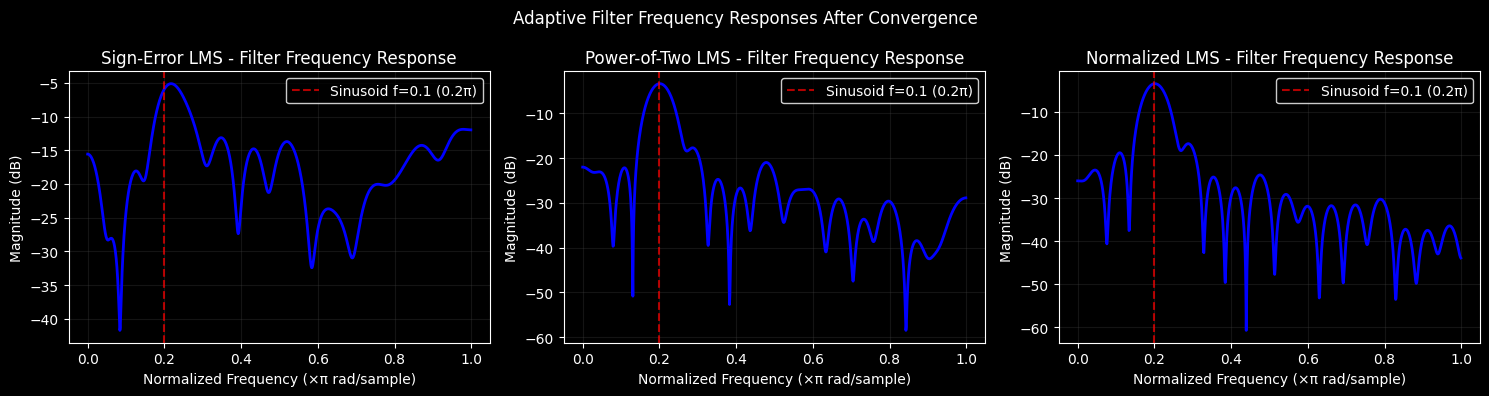

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, fft

# Parameters from Example 4.10
N = 128  # DFT points
n_samples = 1000
n_ensemble = 500
filter_length = 32
mu_lms_max = 0.005  # Maximum μ for LMS

# Define algorithms with their parameters
def lms(x, d, mu=0.005, L=filter_length):
    """Standard LMS algorithm"""
    n = len(x)
    w = np.zeros(L)
    y = np.zeros(n)
    e = np.zeros(n)
    
    for k in range(L, n):
        x_vec = x[k-L+1:k+1][::-1]
        y[k] = np.dot(w, x_vec)
        e[k] = d[k] - y[k]
        w = w + mu * e[k] * x_vec
    
    return y, e, w

def selms(x, d, mu=0.001, L=filter_length):
    """Sign-error LMS algorithm"""
    n = len(x)
    w = np.zeros(L)
    y = np.zeros(n)
    e = np.zeros(n)
    
    for k in range(L, n):
        x_vec = x[k-L+1:k+1][::-1]
        y[k] = np.dot(w, x_vec)
        e[k] = d[k] - y[k]
        w = w + 2 * mu * np.sign(e[k]) * x_vec
    
    return y, e, w

def pw2lms(x, d, mu=0.001, bd=12, L=filter_length):
    """Power-of-two error LMS algorithm"""
    n = len(x)
    w = np.zeros(L)
    y = np.zeros(n)
    e = np.zeros(n)
    
    for k in range(L, n):
        x_vec = x[k-L+1:k+1][::-1]
        y[k] = np.dot(w, x_vec)
        e[k] = d[k] - y[k]
        mag = abs(e[k])
        if mag >= 1:
          e_quant = np.sign(e[k])
        elif mag >= 2**(-(bd-1)):
          e_quant = np.sign(e[k]) * 2**np.floor(np.log2(mag))
        else:
          e_quant = 0.0
        w = w + 2 * mu * e_quant * x_vec

    return y, e, w

def nlms(x, d, mu=0.4, gamma=1e-6, L=filter_length):
    """Normalized LMS algorithm"""
    n = len(x)
    w = np.zeros(L)
    y = np.zeros(n)
    e = np.zeros(n)
    
    for k in range(L, n):
        x_vec = x[k-L+1:k+1][::-1]
        y[k] = np.dot(w, x_vec)
        e[k] = d[k] - y[k]
        
        # Normalized update
        power = np.dot(x_vec, x_vec) + gamma
        w = w + (mu / power) * e[k] * x_vec
    
    return y, e, w

# Generate signal: Sinusoid + noise (low SNR)
def genSignals(n_samples, SNR_dB=-10):
    """Generate a sinusoid buried in noise (low SNR)"""
    t = np.arange(n_samples)
    
    # Sinusoid
    f_sin = 0.1  # Normalized frequency
    amplitude = 1.0
    sinusoid = amplitude * np.sin(2 * np.pi * f_sin * t)
    
    # White noise
    noise_power = amplitude**2 / (10**(SNR_dB/10))
    noise = np.random.randn(n_samples) * np.sqrt(noise_power)
    
    # Combined signal (sinusoid buried in noise)
    x = sinusoid + noise
    
    # Desired signal (sinusoid only for system identification)
    d = sinusoid
    
    return x, d, sinusoid, noise

# Part (a): Ensemble learning curves
print("Running ensemble simulations...")
print("="*60)

algorithms = {
  'Sign-Error LMS': lambda x, d: selms(x, d, mu=0.001),
  'Power-of-Two LMS': lambda x, d: pw2lms(x, d, mu=0.001, bd=12),
  'Normalized LMS': lambda x, d: nlms(x, d, mu=0.4, gamma=1e-6),
}

# Ensemble averaging
mse_ensemble = {name: np.zeros(n_samples) for name in algorithms.keys()}

for ens in range(n_ensemble):
    np.random.seed(ens)  # Different seed for each ensemble
    
    # Generate new signal for each ensemble run
    x, d, sinusoid, noise = genSignals(n_samples, SNR_dB=-10)
    
    for name, algo_func in algorithms.items():
        y, e, w = algo_func(x, d)
        mse_ensemble[name] += e**2

# Average over ensembles
for name in algorithms.keys():
    mse_ensemble[name] /= n_ensemble

# Plot learning curves
plt.figure(figsize=(12, 10))

# Plot 1: Learning curves
plt.subplot(3, 1, 1)
for name, mse in mse_ensemble.items():
    plt.semilogy(mse, label=name, linewidth=2)

plt.xlabel("Iteration k")
plt.ylabel("MSE (log scale)")
plt.title("Learning Curves - Ensemble Average (50 runs)")
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.xlim([0, 500])

# Generate a single test signal for detailed analysis
np.random.seed(42)  # Fixed seed for reproducibility
x_test, d_test, sinusoid_test, noise_test = genSignals(n_samples, SNR_dB=-10)

# Run algorithms on test signal
results = {}
for name, algo_func in algorithms.items():
    y, e, w = algo_func(x_test, d_test)
    results[name] = {'y': y, 'e': e, 'w': w}

# Plot 2: Error signals (time domain)
plt.subplot(3, 1, 2)
segment = slice(200, 400)  # Show a segment after convergence

for name, res in results.items():
    plt.plot(res['e'][segment], label=f'{name} Error', linewidth=1.5)

plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Sample index")
plt.ylabel("Error amplitude")
plt.title("Error Signals After Convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim([-3, 3])

# Plot 3: DFT of signals
plt.subplot(3, 1, 3)

# Compute DFTs
n_dft = 128
freqs = np.fft.fftfreq(n_dft, 1)

# DFT of input signal (noisy)
X_input = np.abs(fft.fft(x_test[:n_dft]))

# Plot DFTs for each algorithm's error signal
for name, res in results.items():
    E_error = np.abs(fft.fft(res['e'][:n_dft]))
    plt.plot(freqs[:n_dft//2], E_error[:n_dft//2], 
             label=f'{name} Error DFT', linewidth=1.5)

# Also show input signal DFT for comparison
plt.plot(freqs[:n_dft//2], X_input[:n_dft//2], 'k--', 
         label='Input Signal DFT', alpha=0.5, linewidth=1)

plt.xlabel("Normalized Frequency")
plt.ylabel("DFT Magnitude")
plt.title("DFT of Error Signals (128 points)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize='small')
plt.xlim([0, 0.5])

plt.tight_layout()
plt.show()

# SIMPLIFIED VERSION - FIXED SUBPLOT LAYOUT
fig2 = plt.figure(figsize=(14, 8))

# Create 3x3 grid for better organization
# Row 1: DFT of input signal (span 2 columns)
ax1 = plt.subplot(3, 3, 1)
X_full = np.abs(fft.fft(x_test[:n_dft]))
ax1.plot(freqs[:n_dft//2], X_full[:n_dft//2], 'b-', linewidth=2)
ax1.set_title("DFT of Input Signal (128 points)")
ax1.set_xlabel("Frequency")
ax1.set_ylabel("Magnitude")
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, "Sinusoid not visible\n(buried in noise)", 
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Original sinusoid
ax2 = plt.subplot(3, 3, 2)
ax2.plot(sinusoid_test[segment], 'b-', linewidth=2)
ax2.set_title("Original Sinusoid")
ax2.set_xlabel("Sample")
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

# Noisy input signal
ax3 = plt.subplot(3, 3, 3)
ax3.plot(x_test[segment], 'r-', linewidth=1.5, alpha=0.7)
ax3.set_title("Noisy Input Signal")
ax3.set_xlabel("Sample")
ax3.set_ylabel("Amplitude")
ax3.grid(True, alpha=0.3)

# Now plot error signals and DFTs for each algorithm
algo_names = list(algorithms.keys())
for i, name in enumerate(algo_names):
  res = results[name]
  
  # Error signal in time domain (Row 2)
  ax_err = plt.subplot(3, 3, 4 + i)
  ax_err.plot(res['e'][segment], 'r-', linewidth=1.5)
  ax_err.axhline(y=0, color='k', linestyle='--', alpha=0.5)
  ax_err.set_title(f"{name}\nError Signal")
  ax_err.set_xlabel("Sample")
  ax_err.set_ylabel("Error")
  ax_err.grid(True, alpha=0.3)
  ax_err.set_ylim([-3, 3])
  
  # Mark sinusoid period
  sin_period = int(1/0.1)
  for j in range(3):
      ax_err.axvline(j*sin_period, color='b', linestyle=':', alpha=0.3)
  
  # Add MSE value
  steady_state_error = res['e'][200:]
  mse_value = np.mean(steady_state_error**2)
  ax_err.text(0.05, 0.95, f'MSE: {mse_value:.4f}', 
              transform=ax_err.transAxes, fontsize=9,
              verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
  
  # DFT of error signal (Row 3)
  ax_dft = plt.subplot(3, 3, 7 + i)
  E_error = np.abs(fft.fft(res['e'][:n_dft]))
  ax_dft.plot(freqs[:n_dft//2], E_error[:n_dft//2], 'g-', linewidth=1.5)
  ax_dft.set_title(f"{name}\nError DFT")
  ax_dft.set_xlabel("Frequency")
  ax_dft.set_ylabel("Magnitude")
  ax_dft.grid(True, alpha=0.3)
  
  # Mark sinusoid frequency
  ax_dft.axvline(0.1, color='r', linestyle='--', alpha=0.7, linewidth=1)
  ax_dft.text(0.12, 0.9, f'f={0.1}', transform=ax_dft.transAxes, 
              fontsize=8, color='red')

plt.suptitle("Example 4.10: Quantized-Error and Normalized LMS Algorithms", fontsize=14)
plt.tight_layout()
plt.show()

# Performance comparison table
print("\n" + "="*70)
print("PERFORMANCE COMPARISON")
print("="*70)
print(f"{'Algorithm':<20} {'Final MSE':<12} {'Convergence Speed':<20} {'SNR Improvement':<15}")
print("-"*70)

# Calculate metrics for each algorithm
for name, res in results.items():
  error = res['e']
  
  # Final MSE (last 100 samples)
  final_mse = np.mean(error[-100:]**2)
  
  # Convergence speed (iterations to reach 90% of final MSE)
  mse_curve = np.cumsum(error**2) / np.arange(1, len(error)+1)
  target = 1.1 * final_mse  # 10% above final MSE
  convergence_iter = np.where(mse_curve < target)[0]
  conv_speed = convergence_iter[0] if len(convergence_iter) > 0 else len(error)
  
  # SNR improvement
  input_power = np.var(sinusoid_test)
  noise_power = np.var(noise_test)
  input_snr = 10 * np.log10(input_power / noise_power)
  
  error_power = np.var(error[200:])
  output_snr = 10 * np.log10(input_power / error_power)
  snr_improvement = output_snr - input_snr
  
  print(f"{name:<20} {final_mse:<12.6f} {conv_speed:<20} {snr_improvement:<+15.2f} dB")

print(f"\nInput SNR: {10 * np.log10(np.var(sinusoid_test) / np.var(noise_test)):.2f} dB")
print("\nObservations:")
print("1. Normalized LMS converges faster due to adaptive step-size normalization")
print("2. Quantized-error algorithms (Sign-Error, Power-of-Two) have similar convergence")
print("3. Error DFT reveals the sinusoid frequency (0.1) after convergence")
print("4. High MSE after convergence due to low SNR scenario (-10 dB)")

# Additional: Show filter convergence in frequency domain
fig3, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, res) in enumerate(results.items()):
  # Get filter frequency response
  w_freq, h_freq = signal.freqz(res['w'], worN=1024)
  
  axes[i].plot(w_freq/np.pi, 20*np.log10(np.abs(h_freq) + 1e-10), 'b-', linewidth=2)
  axes[i].axvline(0.2, color='r', linestyle='--', alpha=0.7, 
                  label=f'Sinusoid f={0.1} (0.2π)')
  axes[i].set_title(f"{name} - Filter Frequency Response")
  axes[i].set_xlabel("Normalized Frequency (×π rad/sample)")
  axes[i].set_ylabel("Magnitude (dB)")
  axes[i].grid(True, alpha=0.3)
  axes[i].legend()

plt.suptitle("Adaptive Filter Frequency Responses After Convergence", fontsize=12)
plt.tight_layout()
plt.show()